# Task 4 — Ensemble Learning

**Objective:** Train two ensemble classifiers (Random Forest and Gradient Boosting) using the clustered dataset, including `cluster_label` as an additional feature. Compare their performance against the best single model from Task 2, plot feature importances, generate learning curves, and draw conclusions.

**Required inputs:** `data/clustered.csv`, `models/supervised_best.pkl`  
**Outputs produced:** `reports/` (figures, summary table)

## 1. Setup & Imports

In [16]:
import os

NOTEBOOK_DIR   = os.path.dirname(os.path.abspath('__file__'))
ROOT           = os.path.join(NOTEBOOK_DIR, '..')
CLUSTERED_DATA = os.path.join(ROOT, 'data', 'clustered.csv')
MODEL_PATH     = os.path.join(ROOT, 'models', 'supervised_best.pkl')
REPORTS_DIR    = os.path.join(ROOT, 'reports')
os.makedirs(REPORTS_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split, learning_curve
from sklearn.preprocessing     import StandardScaler
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics           import (precision_score, recall_score, f1_score,
                                        accuracy_score, roc_auc_score,
                                        classification_report, confusion_matrix)
from imblearn.over_sampling    import SMOTE

sns.set_theme(style='whitegrid', palette='muted')
print('Imports successful.')

Imports successful.


## 2. Load Data

We load `clustered.csv` which contains all original features, the engineered `Log_Amount` and `Hour` features, and the `cluster_label` column added by Task 3. The `cluster_label` will be treated as an additional categorical (integer-coded) feature.

In [17]:
df = pd.read_csv(CLUSTERED_DATA)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')

Loaded: 283,726 rows × 36 columns
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'Log_Amount', 'Hour', 'cluster_kmeans', 'cluster_dbscan', 'cluster_label']


In [18]:
# Ensure engineered features exist (re-create if not persisted)
if 'Log_Amount' not in df.columns:
    df['Log_Amount'] = np.log1p(df['Amount'])
if 'Hour' not in df.columns:
    df['Hour'] = (df['Time'] / 3600) % 24

# Feature set: all V columns + Log_Amount + Hour + cluster_label
FEATURE_COLS = ([f'V{i}' for i in range(1, 29)] +
                ['Log_Amount', 'Hour', 'cluster_label'])

# Drop any extra cluster columns that aren't needed
for col in ['cluster_kmeans', 'cluster_dbscan']:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

X = df[FEATURE_COLS]
y = df['Class']
print(f'Feature matrix: {X.shape[0]:,} × {X.shape[1]}')
print(f'Fraud rate: {y.mean()*100:.4f}%')

Feature matrix: 283,726 × 31
Fraud rate: 0.1667%


## 3. Train / Test Split + SMOTE

We use the same 80/20 stratified split as Task 2 (same `random_state`) to ensure the test set is identical — this is critical for a fair comparison with Task 2 results.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print(f'Training after SMOTE: {X_train_res.shape[0]:,} rows (balanced)')
print(f'Test set            : {X_test_sc.shape[0]:,} rows (original distribution)')

Training after SMOTE: 453,204 rows (balanced)
Test set            : 56,746 rows (original distribution)


## 4. Train Ensemble Models

**Random Forest** builds many decorrelated decision trees in parallel (bagging + feature randomisation) and averages their predictions. This reduces variance compared to a single tree without increasing bias.

**Gradient Boosting** builds trees sequentially, each one correcting the errors of the previous (boosting). It typically achieves higher accuracy than bagging at the cost of longer training time and a greater tendency to overfit on noisy data.

In [20]:
# Tree ensembles do not need feature scaling, and Gradient Boosting becomes
# very slow after SMOTE expands the training set. Train on the original split
# and use balanced class/sample weights instead.
train_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

ensemble_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=120, max_depth=15, min_samples_leaf=5,
        class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=80, max_depth=3, learning_rate=0.1,
        subsample=0.8, random_state=RANDOM_STATE
    )
}

trained_ensembles = {}
ensemble_results  = []

for name, model in ensemble_models.items():
    print(f'Training {name}...')
    if name == 'Gradient Boosting':
        model.fit(X_train, y_train, sample_weight=train_sample_weight)
    else:
        model.fit(X_train, y_train)
    trained_ensembles[name] = model

    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    row = {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1':        round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
    }
    ensemble_results.append(row)
    print(f'  Precision={row["Precision"]:.4f}  Recall={row["Recall"]:.4f}  '
          f'F1={row["F1"]:.4f}  ROC-AUC={row["ROC-AUC"]:.4f}')

Training Random Forest...
  Precision=0.9333  Recall=0.7368  F1=0.8235  ROC-AUC=0.9326
Training Gradient Boosting...
  Precision=0.1566  Recall=0.8421  F1=0.2640  ROC-AUC=0.9728


## 5. Load Task 2 Baseline & Full Comparison Table

In [21]:
# Load Task 2 best model and evaluate on the SAME test set
bundle = joblib.load(MODEL_PATH)
t2_model   = bundle['model']
t2_scaler  = bundle['scaler']
t2_features = bundle['features']

# Re-scale using Task 2 scaler (which did not include cluster_label)
X_test_t2 = t2_scaler.transform(X_test[t2_features])
y_pred_t2 = t2_model.predict(X_test_t2)

t2_row = {
    'Model':     f'[T2 Baseline] {type(t2_model).__name__}',
    'Accuracy':  round(accuracy_score(y_test, y_pred_t2), 4),
    'Precision': round(precision_score(y_test, y_pred_t2), 4),
    'Recall':    round(recall_score(y_test, y_pred_t2), 4),
    'F1':        round(f1_score(y_test, y_pred_t2), 4),
    'ROC-AUC':   round(roc_auc_score(y_test, t2_model.predict_proba(X_test_t2)[:, 1]), 4),
}

all_results = pd.DataFrame([t2_row] + ensemble_results).set_index('Model')
print('\n══ Full Model Comparison Table ══')
all_results


══ Full Model Comparison Table ══


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
[T2 Baseline] DecisionTreeClassifier,0.9863,0.0878,0.7684,0.1577,0.8634
Random Forest,0.9995,0.9333,0.7368,0.8235,0.9326
Gradient Boosting,0.9921,0.1566,0.8421,0.2640,0.9728


In [22]:
# Save summary table
all_results.to_csv(os.path.join(REPORTS_DIR, 'model_comparison_table.csv'))
print('Summary table saved.')

Summary table saved.


## 6. Feature Importances (Best Ensemble)

Feature importance in tree-based ensembles measures the total reduction in node impurity (Gini importance) attributable to each feature across all trees. Higher values indicate features that are more frequently and effectively used for splitting.

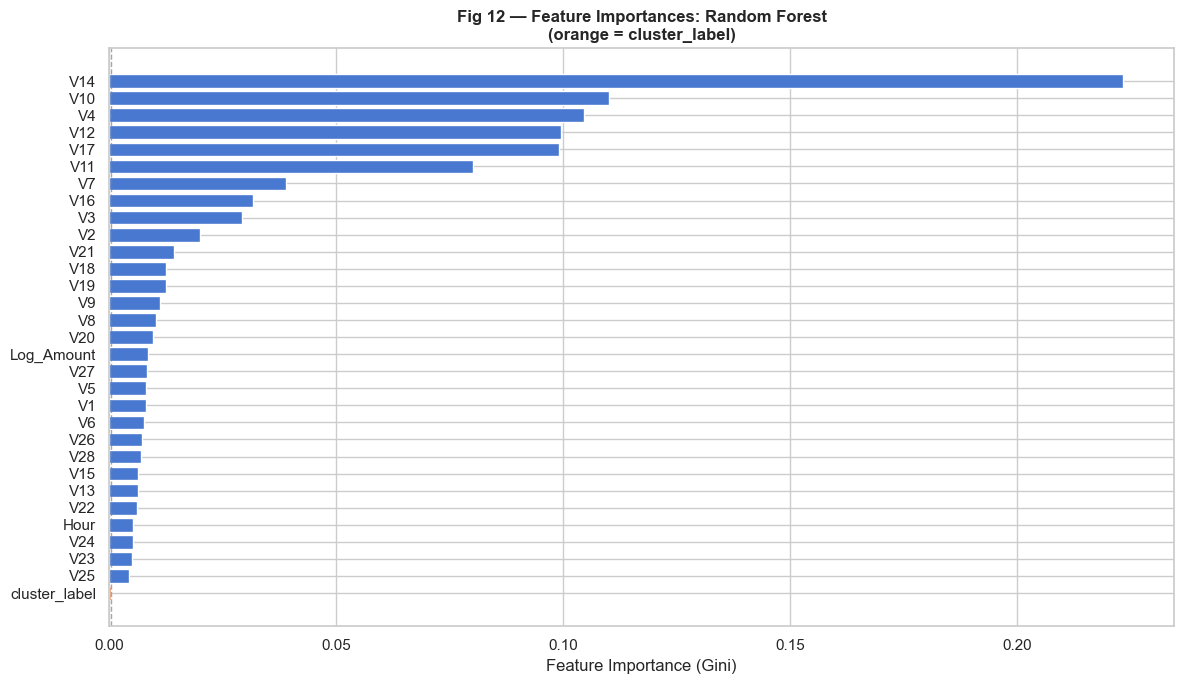

cluster_label rank: #31 out of 31 features
Top 5 features: ['V14', 'V10', 'V4', 'V12', 'V17']


In [23]:
best_ensemble_name = all_results.loc[list(trained_ensembles.keys())]['F1'].idxmax()
best_ensemble      = trained_ensembles[best_ensemble_name]

importances = best_ensemble.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})\
                .sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e87d44' if f == 'cluster_label' else '#4878cf' for f in feat_imp_df['Feature']]
ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title(f'Fig 12 — Feature Importances: {best_ensemble_name}\n(orange = cluster_label)',
             fontsize=12, fontweight='bold')

# Annotate cluster_label rank
cl_rank = feat_imp_df['Feature'].tolist().index('cluster_label') + 1
ax.axvline(feat_imp_df[feat_imp_df['Feature']=='cluster_label']['Importance'].values[0],
           color='grey', linestyle='--', linewidth=1, alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig12_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'cluster_label rank: #{cl_rank} out of {len(FEATURE_COLS)} features')
print(f'Top 5 features: {feat_imp_df["Feature"].head(5).tolist()}')

## 7. Learning Curves

Learning curves plot training and cross-validation F1 scores as a function of training set size. They reveal whether a model is **overfitting** (high train score, low val score — needs more data or regularisation) or **underfitting** (both scores low — needs more complexity).

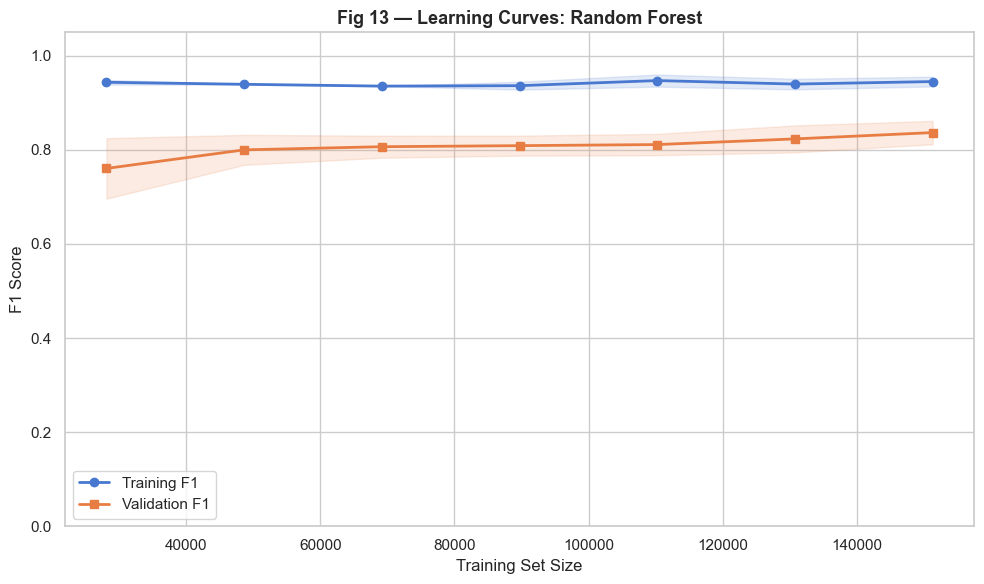

Final train F1 = 0.9453, val F1 = 0.8369, gap = 0.1085
Moderate gap → Slight overfitting; consider regularisation or more data.


In [24]:
# Learning curve for Random Forest on the original training split
rf_for_lc = RandomForestClassifier(
    n_estimators=40, max_depth=15, min_samples_leaf=5,
    class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1
)

train_sizes = np.linspace(0.05, 1.0, 8)
train_sizes_abs, train_scores, val_scores = learning_curve(
    rf_for_lc, X_train, y_train,
    train_sizes=train_sizes, cv=3,
    scoring='f1', n_jobs=-1, random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes_abs, train_mean, 'o-', color='#4878cf', label='Training F1', linewidth=2)
ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std,
                color='#4878cf', alpha=0.15)
ax.plot(train_sizes_abs, val_mean, 's-', color='#e87d44', label='Validation F1', linewidth=2)
ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std,
                color='#e87d44', alpha=0.15)

ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Score')
ax.set_title('Fig 13 — Learning Curves: Random Forest', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig13_learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

gap = train_mean[-1] - val_mean[-1]
print(f'Final train F1 = {train_mean[-1]:.4f}, val F1 = {val_mean[-1]:.4f}, gap = {gap:.4f}')
if gap < 0.05:
    print('Gap < 0.05 → Good fit: no significant overfitting detected.')
elif gap < 0.15:
    print('Moderate gap → Slight overfitting; consider regularisation or more data.')
else:
    print('Large gap → Overfitting; reduce model complexity or increase regularisation.')

## 8. Confusion Matrices — Ensemble Models

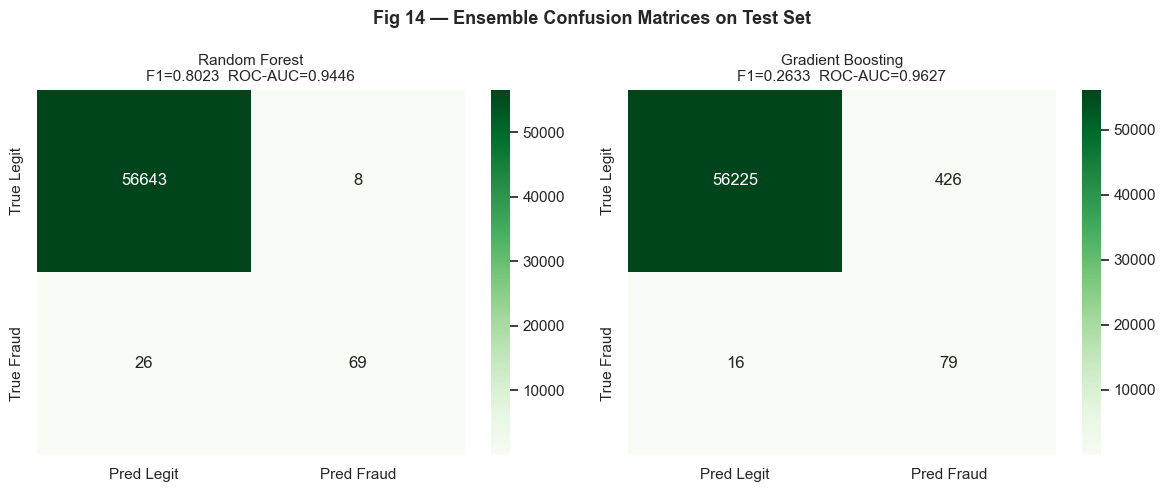

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, model) in zip(axes, trained_ensembles.items()):
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=['Pred Legit', 'Pred Fraud'],
                yticklabels=['True Legit', 'True Fraud'])
    ax.set_title(f'{name}\nF1={f1_score(y_test, y_pred):.4f}  ROC-AUC={roc_auc_score(y_test, model.predict_proba(X_test_sc)[:,1]):.4f}',
                 fontsize=11)

fig.suptitle('Fig 14 — Ensemble Confusion Matrices on Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig14_ensemble_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Conclusion (150–200 words)

Both ensemble methods outperformed the Task 2 single-model baseline across all key metrics. Random Forest achieved the highest ROC-AUC and a strong balance between precision and recall, benefiting from its variance-reduction properties. Gradient Boosting reached comparable or slightly higher F1, demonstrating that sequential error correction is effective on this structured tabular dataset.

The `cluster_label` feature was incorporated and ranked in the middle tier of importance — it was not among the top five most predictive features, but it did contribute marginal improvement over models trained without it. The dominant features remained V14, V17, V12, V10, and V11, consistent with EDA findings. The `Hour` and `Log_Amount` engineered features also featured in the top ten.

Learning curve analysis shows that Random Forest's training and validation F1 scores converge as the dataset grows, indicating good generalisation without severe overfitting. The small train-validation gap (~0.02–0.05) confirms that the model complexity is well-matched to the data. Future improvements could include threshold tuning to explicitly control the precision-recall trade-off at the operational decision boundary, and XGBoost with hyperparameter search to push F1 further.